# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

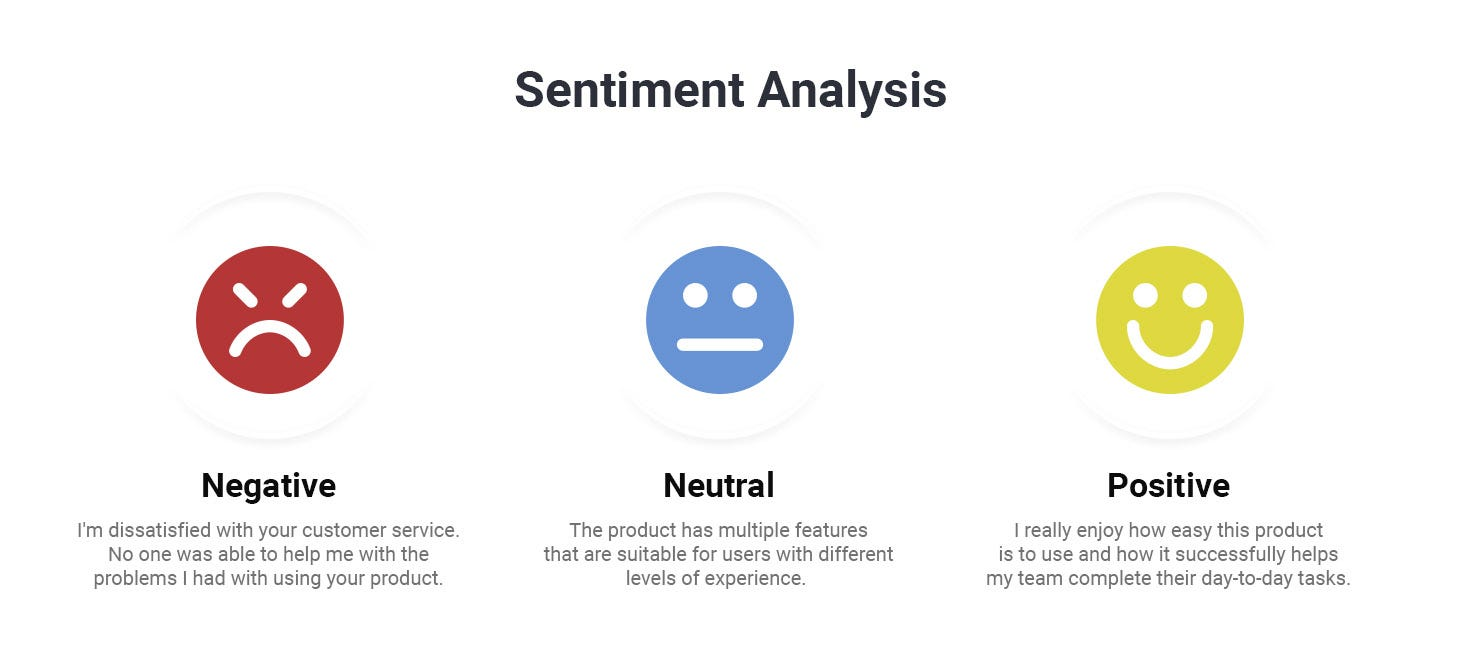

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [1]:
# Load the dataset
import pandas as pd

data = pd.read_csv('/content/DisneylandReviews.csv', encoding='latin-1')
data

FileNotFoundError: [Errno 2] No such file or directory: '/content/DisneylandReviews.csv'

In [ ]:
#Check for missing values
data.isna().sum()

In [ ]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [ ]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

In [ ]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [ ]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\najaf\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# Load the dataset
amazon_data = pd.read_csv('Amazon_Unlocked_Mobile.csv')
amazon_data.head()

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [3]:
# Check the shape and missing values
print(amazon_data.shape)
amazon_data.isna().sum()

(413840, 6)


Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64

In [4]:
# Drop rows where the review text or rating is missing
amazon_data = amazon_data.dropna(subset=['Reviews', 'Rating'])
print(amazon_data.shape)

(413770, 6)


In [5]:
# Create a Sentiment label from the star Rating (same logic as the Disneyland example)
amazon_data['Sentiment'] = amazon_data['Rating'].apply(
    lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral')
)
amazon_data['Sentiment'].value_counts()

Sentiment
positive    284948
negative     97059
neutral      31763
Name: count, dtype: int64

In [6]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 1]

    return ' '.join(words)

amazon_data['Reviews_clean'] = amazon_data['Reviews'].apply(preprocess_text)
amazon_data[['Reviews_clean', 'Sentiment']].head()

,Reviews_clean,Sentiment
0,feel lucky found used phone us used hard phone...,positive
1,nice phone nice grade pantach revue clean set ...,positive
2,pleased,positive
3,works good goes slow sometimes good phone love,positive
4,great phone replace lost phone thing volume bu...,positive


In [7]:
# Stratify on Sentiment so the class balance is preserved in both splits
train_data, test_data, train_labels, test_labels = train_test_split(
    amazon_data['Reviews_clean'],
    amazon_data['Sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=amazon_data['Sentiment']
)

print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (331016,)
test_data size: (82754,)


In [8]:
# Limit the vocabulary to the 5000 most informative tokens
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

print(train_vectors.shape, test_vectors.shape)

(331016, 5000) (82754, 5000)


In [9]:
# MultinomialNB works well with the non-negative TF-IDF features
nb_classifier = MultinomialNB()
nb_classifier.fit(train_vectors, train_labels)

MultinomialNB()

In [10]:
# Predictions on the test set
predictions = nb_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

print("Classification Report:")
print(classification_report(test_labels, predictions))

Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.74      0.77     19412
     neutral       0.36      0.05      0.08      6352
    positive       0.86      0.97      0.91     56990

    accuracy                           0.84     82754
   macro avg       0.67      0.58      0.59     82754
weighted avg       0.81      0.84      0.81     82754



Confusion Matrix:
[[14289   165  4958]
 [ 1913   299  4140]
 [ 1608   373 55009]]


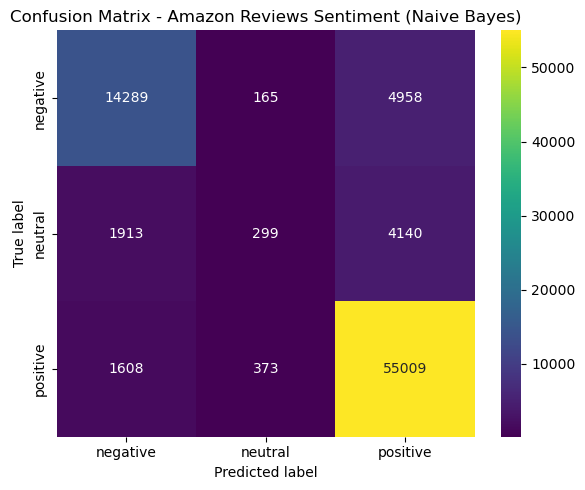

In [11]:
labels_order = ['negative', 'neutral', 'positive']
cm = confusion_matrix(test_labels, predictions, labels=labels_order)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - Amazon Reviews Sentiment (Naive Bayes)')
plt.tight_layout()
plt.show()